In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from google.colab import drive
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from imblearn.over_sampling import SMOTE
from collections import Counter
from xgboost import XGBClassifier
import shap
from IPython.display import Markdown, display

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
file_path = '/content/drive/MyDrive/tese André mg feuc/datasets/stress perguntas dataset/Stress Dataset.csv'
df = pd.read_csv(file_path)

# Data Cleaning
initial_shape = df.shape
df = df.drop_duplicates()
df = df.dropna()

print(f'Original dataset shape: {initial_shape}')
print(f'Dataset shape after cleaning: {df.shape}')
display(df.head())

Original dataset shape: (843, 26)
Dataset shape after cleaning: (816, 26)


,Gender,Age,Have you recently experienced stress in your life?,Have you noticed a rapid heartbeat or palpitations?,Have you been dealing with anxiety or tension recently?,Do you face any sleep problems or difficulties falling asleep?,Have you been dealing with anxiety or tension recently?.1,Have you been getting headaches more often than usual?,Do you get irritated easily?,Do you have trouble concentrating on your academic tasks?,...,Are you facing any difficulties with your professors or instructors?,Is your working environment unpleasant or stressful?,Do you struggle to find time for relaxation and leisure activities?,Is your hostel or home environment causing you difficulties?,Do you lack confidence in your academic performance?,Do you lack confidence in your choice of academic subjects?,Academic and extracurricular activities conflicting for you?,Do you attend classes regularly?,Have you gained/lost weight?,Which type of stress do you primarily experience?
0,0,20,3,4,2,5,1,2,1,2,...,3,1,4,1,2,1,3,1,2,Eustress (Positive Stress) - Stress that motiv...
1,0,20,2,3,2,1,1,1,1,4,...,3,2,1,1,3,2,1,4,2,Eustress (Positive Stress) - Stress that motiv...
2,0,20,5,4,2,2,1,3,4,2,...,2,2,2,1,4,1,1,2,1,Eustress (Positive Stress) - Stress that motiv...
3,1,20,3,4,3,2,2,3,4,3,...,1,1,2,1,2,1,1,5,3,Eustress (Positive Stress) - Stress that motiv...
4,0,20,3,3,3,2,2,4,4,4,...,2,3,1,2,2,4,2,2,2,Eustress (Positive Stress) - Stress that motiv...


In [ ]:
target_column = 'Which type of stress do you primarily experience?'

class_counts = df[target_column].value_counts()
class_percentages = df[target_column].value_counts(normalize=True) * 100

display(Markdown(f"### Class Counts for '{target_column}'"))
display(class_counts.to_frame(name='Count'))

display(Markdown(f"### Class Percentages for '{target_column}'"))
display(class_percentages.to_frame(name='Percentage'))

### Class Counts for 'Which type of stress do you primarily experience?'

,Count
Which type of stress do you primarily experience?,
Eustress (Positive Stress) - Stress that motivates and enhances performance.,745
No Stress - Currently experiencing minimal to no stress.,42
Distress (Negative Stress) - Stress that causes anxiety and impairs well-being.,29


### Class Percentages for 'Which type of stress do you primarily experience?'

,Percentage
Which type of stress do you primarily experience?,
Eustress (Positive Stress) - Stress that motivates and enhances performance.,91.299020
No Stress - Currently experiencing minimal to no stress.,5.147059
Distress (Negative Stress) - Stress that causes anxiety and impairs well-being.,3.553922


/tmp/ipykernel_2991/2123596316.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=target_column, order=df[target_column].value_counts().index, palette='viridis')


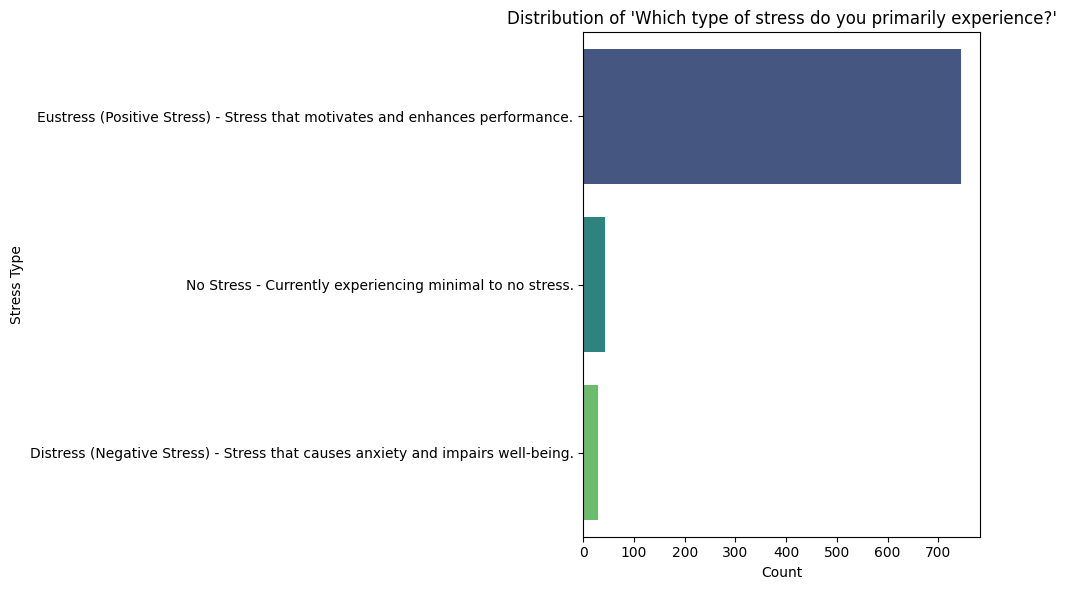

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, y=target_column, order=df[target_column].value_counts().index, palette='viridis')
plt.title(f'Distribution of \'{target_column}\'')
plt.xlabel('Count')
plt.ylabel('Stress Type')
plt.tight_layout()
plt.show()

In [ ]:
max_percentage = class_percentages.max()

display(Markdown(f"### Class Imbalance Analysis for '{target_column}'"))
if max_percentage > 80:
    display(Markdown(f"The class imbalance is **severe** with the majority class making up {max_percentage:.2f}% of the data."))
elif max_percentage > 60:
    display(Markdown(f"The class imbalance is **moderate** with the majority class making up {max_percentage:.2f}% of the data."))
else:
    display(Markdown(f"The class imbalance is **not severe or moderate** with the majority class making up {max_percentage:.2f}% of the data."))

### Class Imbalance Analysis for 'Which type of stress do you primarily experience?'

The class imbalance is **severe** with the majority class making up 91.30% of the data.

### Unique values in the target column

In [ ]:
# 1. Show unique values of the target column
print(f"Unique values in '{target_column}':\n{df[target_column].unique()}")

Unique values in 'Which type of stress do you primarily experience?':
['Eustress (Positive Stress) - Stress that motivates and enhances performance.'
 'No Stress - Currently experiencing minimal to no stress.'
 'Distress (Negative Stress) - Stress that causes anxiety and impairs well-being.']


### Ordinal Mapping Creation and Application

In [ ]:
# Distress (Negative Stress) -> 0 (lowest/most negative)
# No Stress -> 1 (neutral)
# Eustress (Positive Stress) -> 2 (highest/most positive)

ordinal_mapping = {
    'Distress (Negative Stress) - Stress that causes anxiety and impairs well-being.': 0,
    'No Stress - Currently experiencing minimal to no stress.': 1,
    'Eustress (Positive Stress) - Stress that motivates and enhances performance.': 2
}

# 3. Apply the mapping and create a new column
df['stress_type_encoded'] = df[target_column].map(ordinal_mapping)

# 4. Confirm the mapping by showing the first 5 lines with both columns
display(df[[target_column, 'stress_type_encoded']].head())

,Which type of stress do you primarily experience?,stress_type_encoded
0,Eustress (Positive Stress) - Stress that motiv...,2
1,Eustress (Positive Stress) - Stress that motiv...,2
2,Eustress (Positive Stress) - Stress that motiv...,2
3,Eustress (Positive Stress) - Stress that motiv...,2
4,Eustress (Positive Stress) - Stress that motiv...,2


### Exploratory Data Analysis (EDA)

#### 1. Distribuição de cada variável numérica (histogramas em grid)

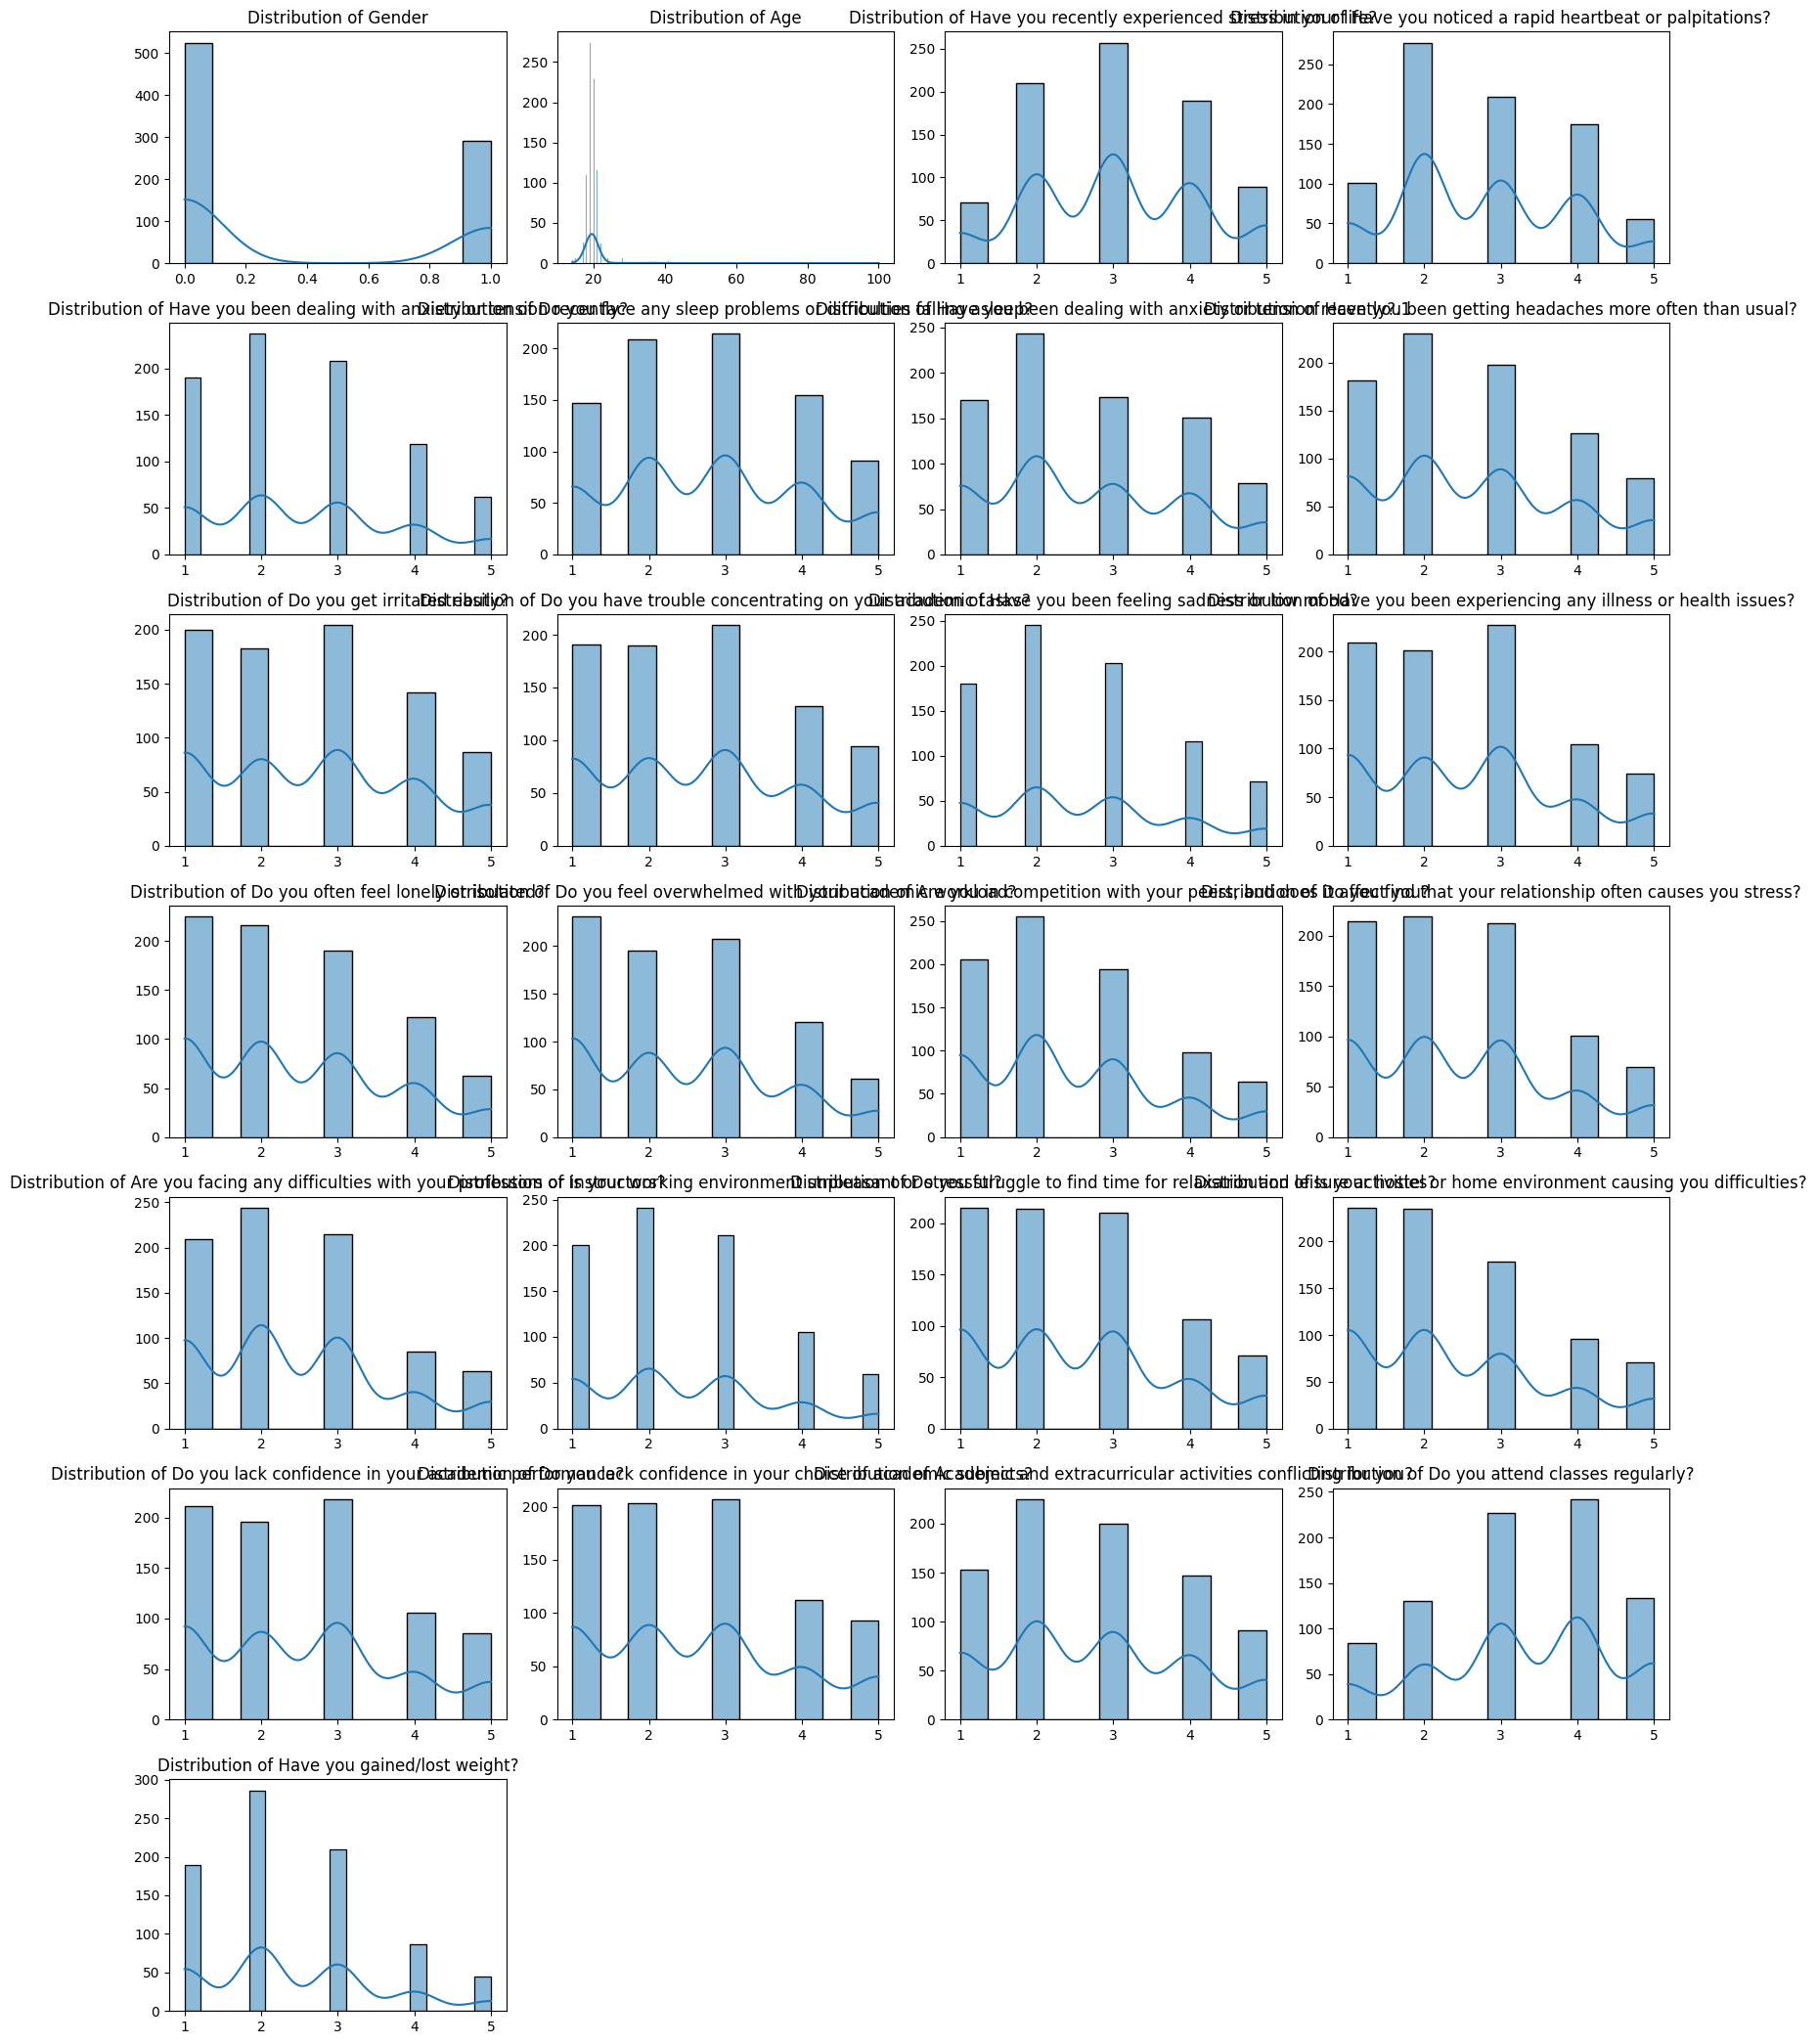

In [ ]:
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
# Exclude the encoded target itself from being plotted as a feature distribution
if 'stress_type_encoded' in numerical_cols:
    numerical_cols.remove('stress_type_encoded')

# Calculate the number of rows and columns for the grid
num_numerical_cols = len(numerical_cols)
num_cols = 4 # Number of columns in the grid
num_rows = (num_numerical_cols + num_cols - 1) // num_cols # Ceiling division

plt.figure(figsize=(num_cols * 4, num_rows * 3))
for i, col in enumerate(numerical_cols):
    plt.subplot(num_rows, num_cols, i + 1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel('')
    plt.ylabel('')
plt.tight_layout()
plt.show()

#### 2. Boxplots de cada variável numérica agrupada por `stress_type_encoded`

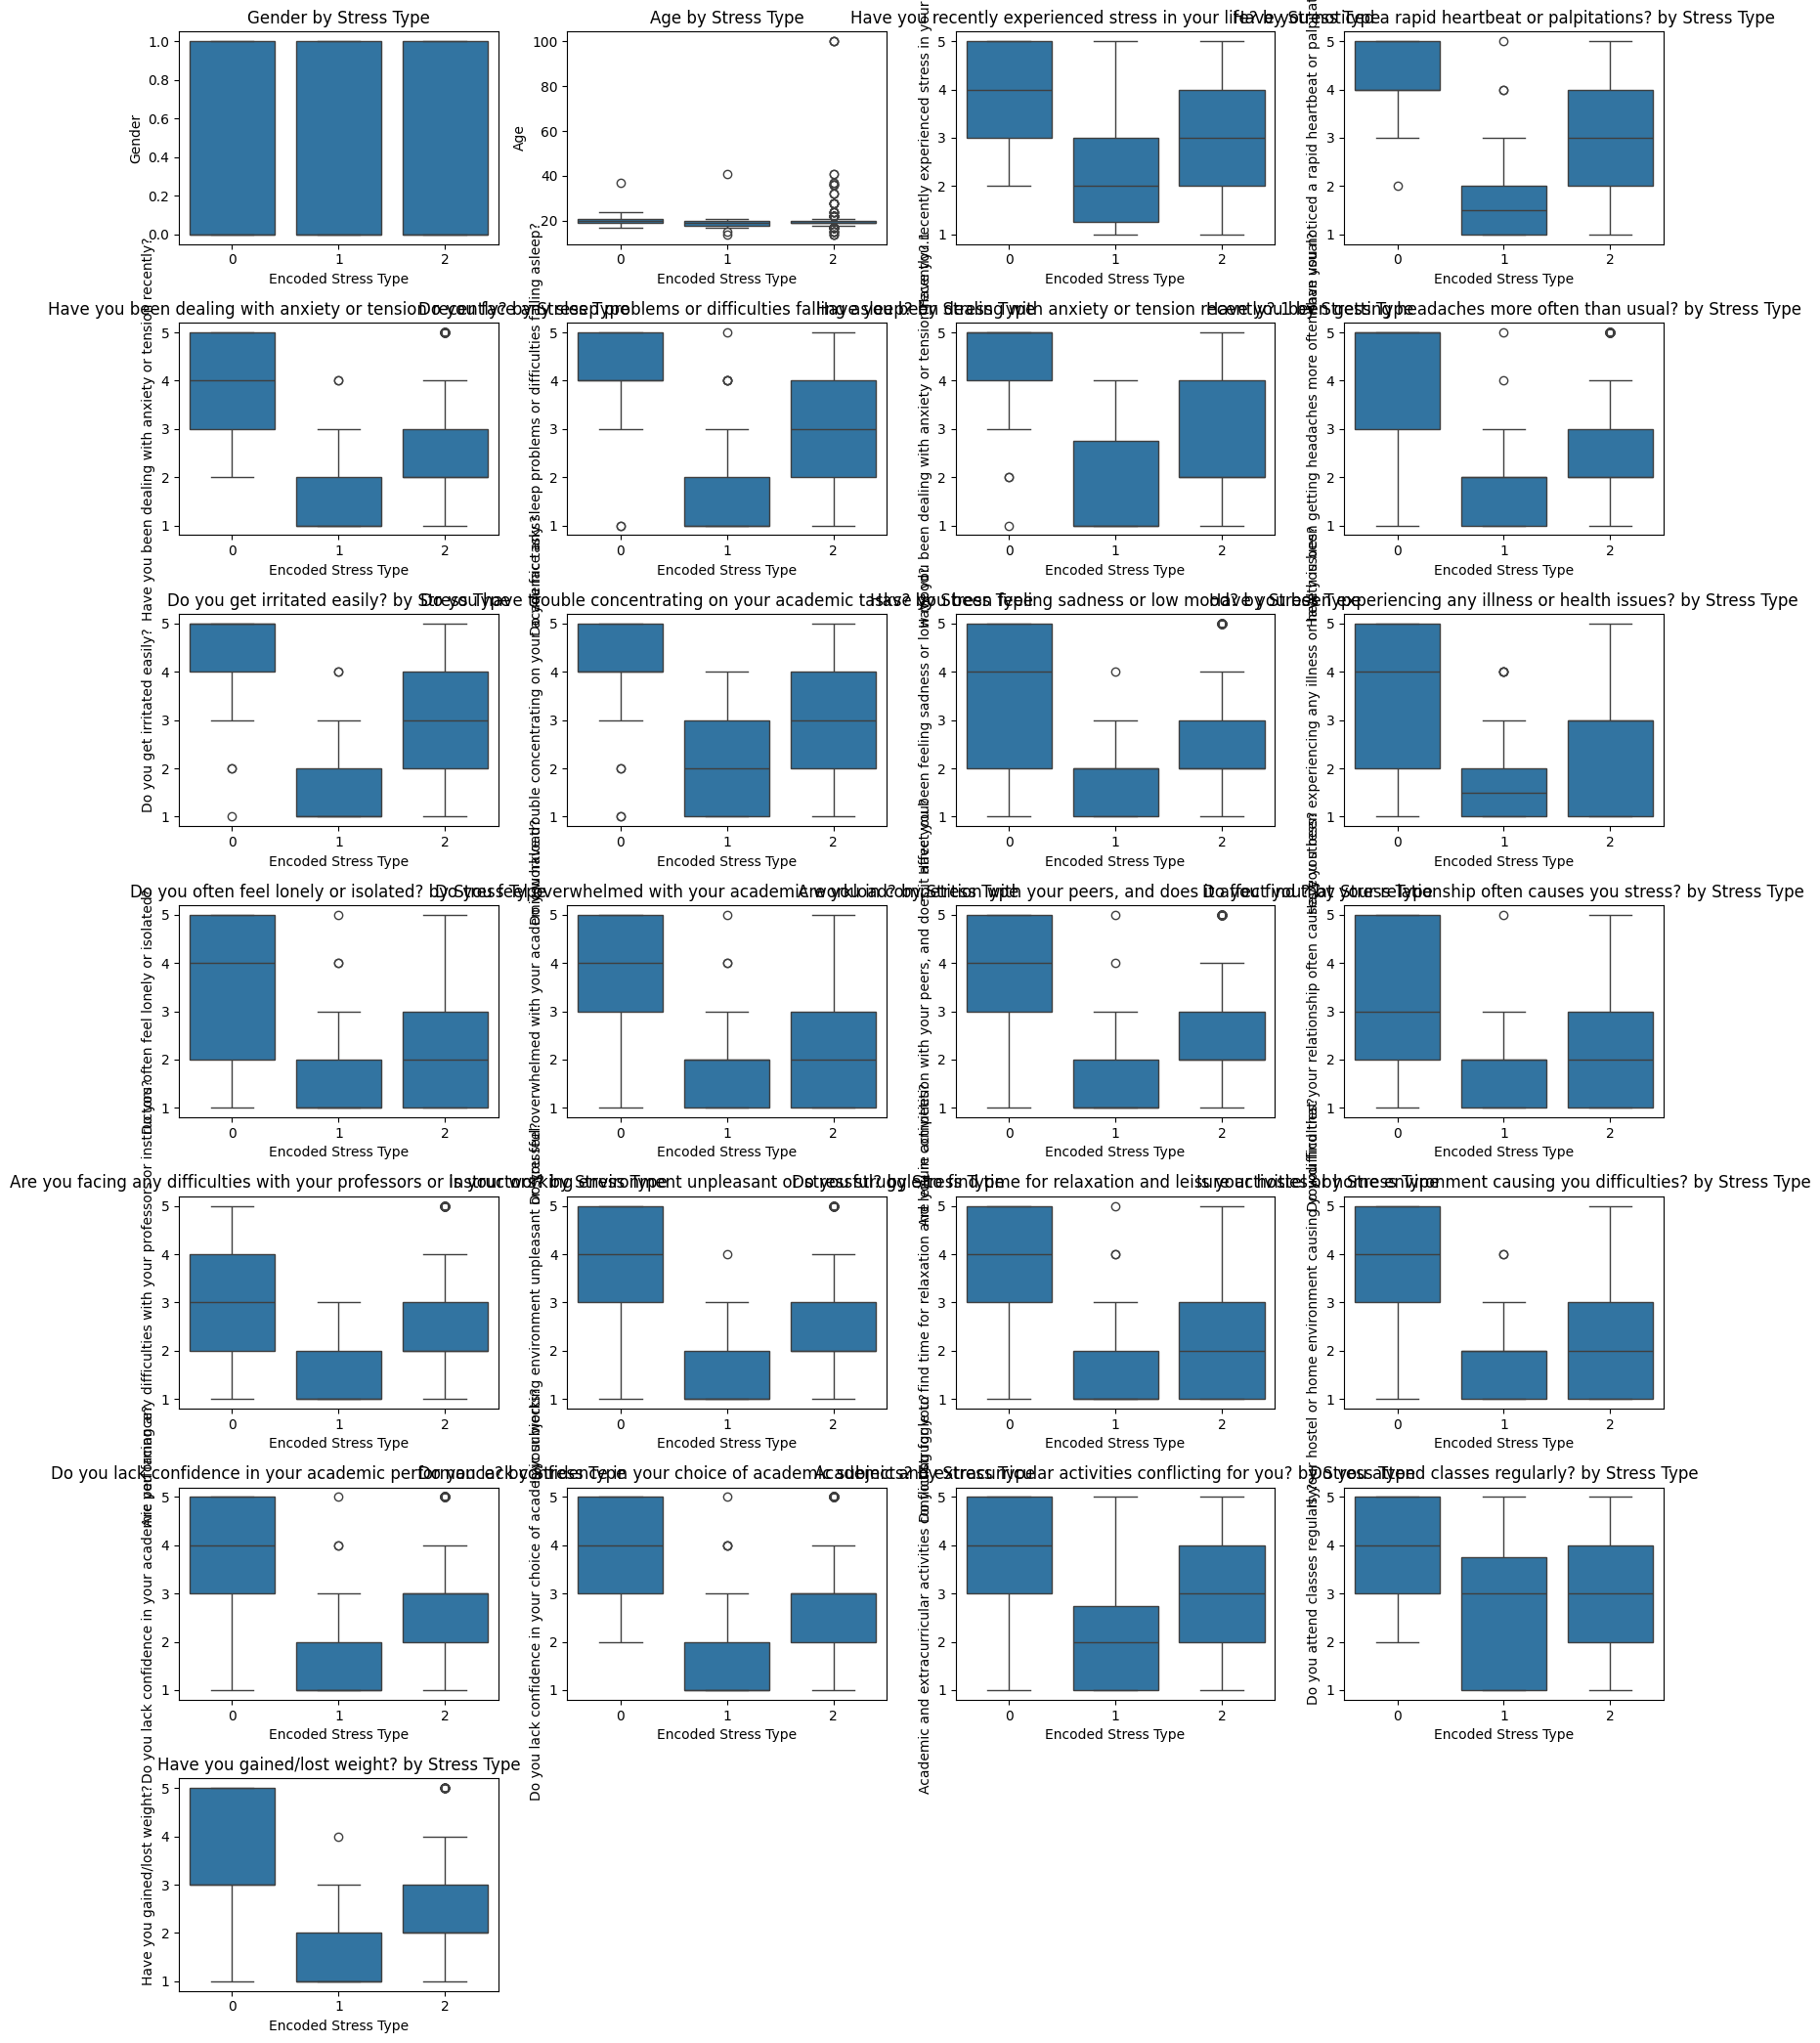

In [ ]:
plt.figure(figsize=(num_cols * 4, num_rows * 3))
for i, col in enumerate(numerical_cols):
    plt.subplot(num_rows, num_cols, i + 1)
    sns.boxplot(x='stress_type_encoded', y=col, data=df)
    plt.title(f'{col} by Stress Type')
    plt.xlabel('Encoded Stress Type')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

#### 3. Heatmap de correlação entre todas as variáveis numéricas

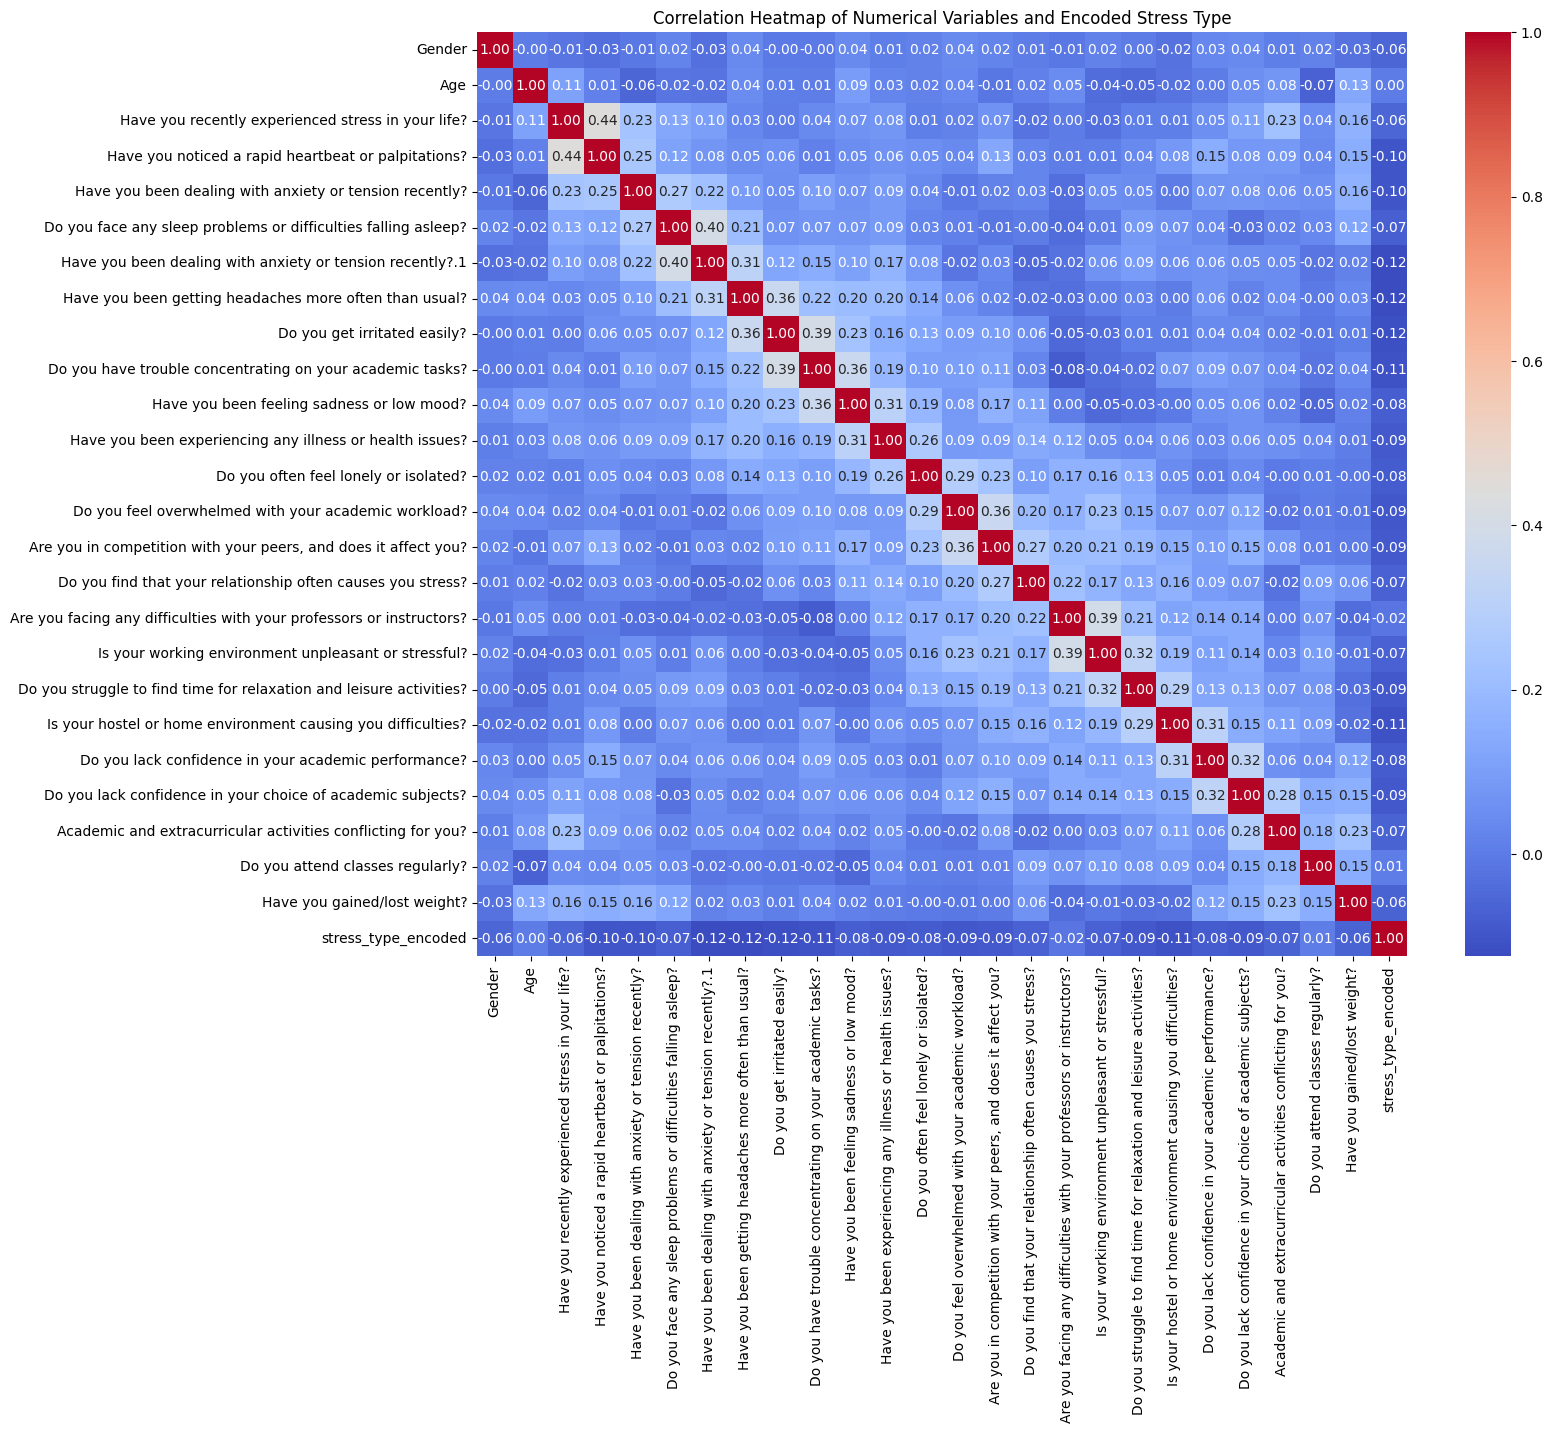

In [ ]:
correlation_matrix = df[numerical_cols + ['stress_type_encoded']].corr()
plt.figure(figsize=(15, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Variables and Encoded Stress Type')
plt.show()

#### 4. Distribuição do target por categoria para variáveis categóricas (Gender)

In [ ]:
categorical_cols = df.select_dtypes(include='object').columns.tolist()
# Exclude the original target column as it's already encoded
if target_column in categorical_cols:
    categorical_cols.remove(target_column)

# Assuming 'Gender' is the only relevant categorical column from previous context
# If there are other categorical columns, this loop will handle them too.
for col in categorical_cols:
    plt.figure(figsize=(8, 6))
    sns.countplot(x=col, hue='stress_type_encoded', data=df, palette='viridis')
    plt.title(f'Distribution of Encoded Stress Type by {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.legend(title='Encoded Stress Type')
    plt.tight_layout()
    plt.show()

### Preparing Data for Modeling: Defining X and y, Encoding Categorical Variables, and Splitting Data

In [ ]:
# 1. Define X (features) and y (target)
X = df.drop(columns=[target_column, 'stress_type_encoded'])
y = df['stress_type_encoded']

print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")

Shape of X: (816, 25)
Shape of y: (816,)


In [ ]:
# 3. Encode categorical variables in X
categorical_cols = X.select_dtypes(include=['object']).columns

if len(categorical_cols) > 0:
    print(f"Categorical columns to encode: {list(categorical_cols)}")
    X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)
    print("Categorical columns encoded using one-hot encoding.")
else:
    print("No categorical columns found in X for encoding.")

print(f"Shape of X after encoding: {X.shape}")

No categorical columns found in X for encoding.
Shape of X after encoding: (816, 25)


In [ ]:
# 4. Divide into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (652, 25)
X_test shape: (164, 25)
y_train shape: (652,)
y_test shape: (164,)


In [ ]:
# 5. Show distribution of y in train and test to confirm stratification

display(Markdown("### Distribution of y in Training Set"))
display(y_train.value_counts(normalize=True) * 100)

display(Markdown("### Distribution of y in Test Set"))
display(y_test.value_counts(normalize=True) * 100)

### Distribution of y in Training Set

,proportion
stress_type_encoded,
2,91.257669
1,5.214724
0,3.527607


### Distribution of y in Test Set

,proportion
stress_type_encoded,
2,91.463415
1,4.878049
0,3.658537


### Applying SMOTE to Balance Training Data

In [ ]:
# 1. Apply SMOTE only on X_train and y_train
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print("Shape of X_train after SMOTE:", X_train_res.shape)
print("Shape of y_train after SMOTE:", y_train_res.shape)

Shape of X_train after SMOTE: (1785, 25)
Shape of y_train after SMOTE: (1785,)


In [ ]:
# 2. Show the distribution of classes before and after SMOTE

display(Markdown("### Class Distribution Before SMOTE (y_train)"))
display(y_train.value_counts())

display(Markdown("### Class Distribution After SMOTE (y_train_res)"))
display(y_train_res.value_counts())

### Class Distribution Before SMOTE (y_train)

,count
stress_type_encoded,
2,595
1,34
0,23


### Class Distribution After SMOTE (y_train_res)

,count
stress_type_encoded,
2,595
1,595
0,595


### Model Training and Evaluation

#### Random Forest Classifier

Random Forest Classifier Evaluation:

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.50      0.67         6
           1       1.00      0.62      0.77         8
           2       0.96      1.00      0.98       150

    accuracy                           0.96       164
   macro avg       0.99      0.71      0.81       164
weighted avg       0.96      0.96      0.96       164

Macro F1-score: 0.8054

Accuracy: 0.9634



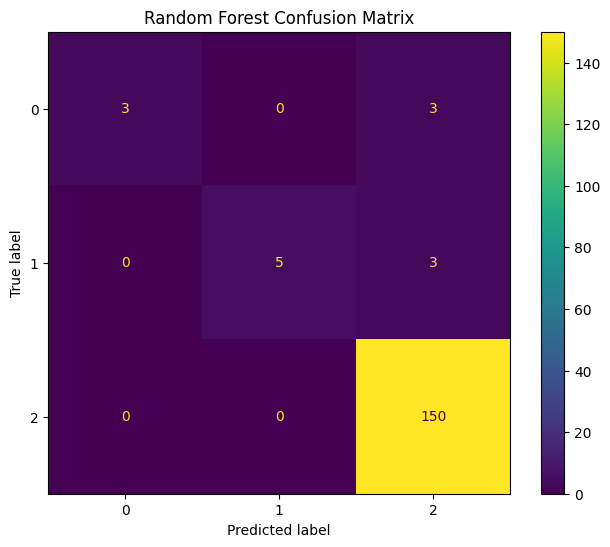

In [ ]:
# 1. Train Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_res, y_train_res)

# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test)

print("Random Forest Classifier Evaluation:\n")

# Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred_rf))

# Macro F1-score
from sklearn.metrics import f1_score
f1_macro_rf = f1_score(y_test, y_pred_rf, average='macro')
print(f"Macro F1-score: {f1_macro_rf:.4f}\n")

# Accuracy
from sklearn.metrics import accuracy_score
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Accuracy: {accuracy_rf:.4f}\n")

# Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=rf_model.classes_)
fig, ax = plt.subplots(figsize=(8, 6))
disp_rf.plot(cmap='viridis', ax=ax)
plt.title('Random Forest Confusion Matrix')
plt.show()

#### XGBoost Classifier

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:44:51] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Classifier Evaluation:

Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.83      0.71         6
           1       0.62      0.62      0.62         8
           2       0.97      0.96      0.97       150

    accuracy                           0.94       164
   macro avg       0.74      0.81      0.77       164
weighted avg       0.94      0.94      0.94       164

Macro F1-score: 0.7686

Accuracy: 0.9390



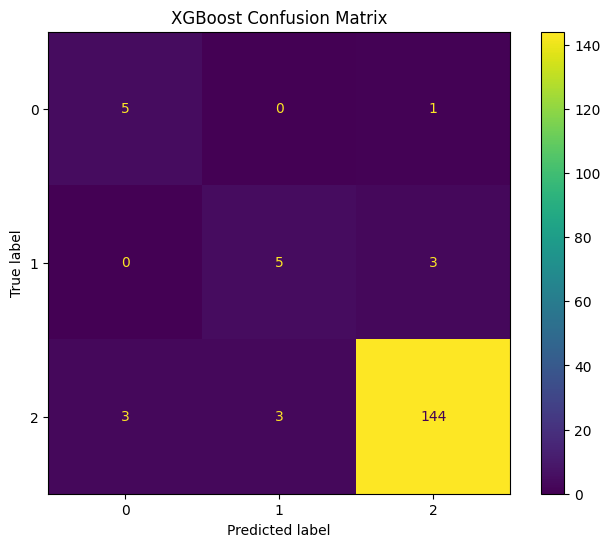

In [ ]:
# 2. Train XGBoost Classifier
xgb_model = XGBClassifier(n_estimators=100, random_state=42, use_label_encoder=False, eval_metric='mlogloss')
xgb_model.fit(X_train_res, y_train_res)

# Make predictions on the test set
y_pred_xgb = xgb_model.predict(X_test)

print("XGBoost Classifier Evaluation:\n")

# Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred_xgb))

# Macro F1-score
f1_macro_xgb = f1_score(y_test, y_pred_xgb, average='macro')
print(f"Macro F1-score: {f1_macro_xgb:.4f}\n")

# Accuracy
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
print(f"Accuracy: {accuracy_xgb:.4f}\n")

# Confusion Matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
disp_xgb = ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=xgb_model.classes_)
fig, ax = plt.subplots(figsize=(8, 6))
disp_xgb.plot(cmap='viridis', ax=ax)
plt.title('XGBoost Confusion Matrix')
plt.show()

### Feature Importance from Random Forest Model

In [ ]:
# 1. Extract feature importance from the Random Forest model
feature_importances = pd.Series(rf_model.feature_importances_, index=X.columns)

# Sort features by importance in descending order
top_15_features = feature_importances.nlargest(15)

display(Markdown("### Top 15 Feature Importances (Random Forest)"))
display(top_15_features.to_frame(name='Importance'))

### Top 15 Feature Importances (Random Forest)

,Importance
Have you noticed a rapid heartbeat or palpitations?,0.110178
Do you get irritated easily?,0.109402
Do you lack confidence in your academic performance?,0.075355
Have you been dealing with anxiety or tension recently?.1,0.065612
Do you face any sleep problems or difficulties falling asleep?,0.051875
Have you recently experienced stress in your life?,0.051282
Do you have trouble concentrating on your academic tasks?,0.049897
Do you struggle to find time for relaxation and leisure activities?,0.044539
Have you been feeling sadness or low mood?,0.044338
Have you been experiencing any illness or health issues?,0.041810


/tmp/ipykernel_2991/1357435776.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_15_features.values, y=top_15_features.index, palette='viridis')


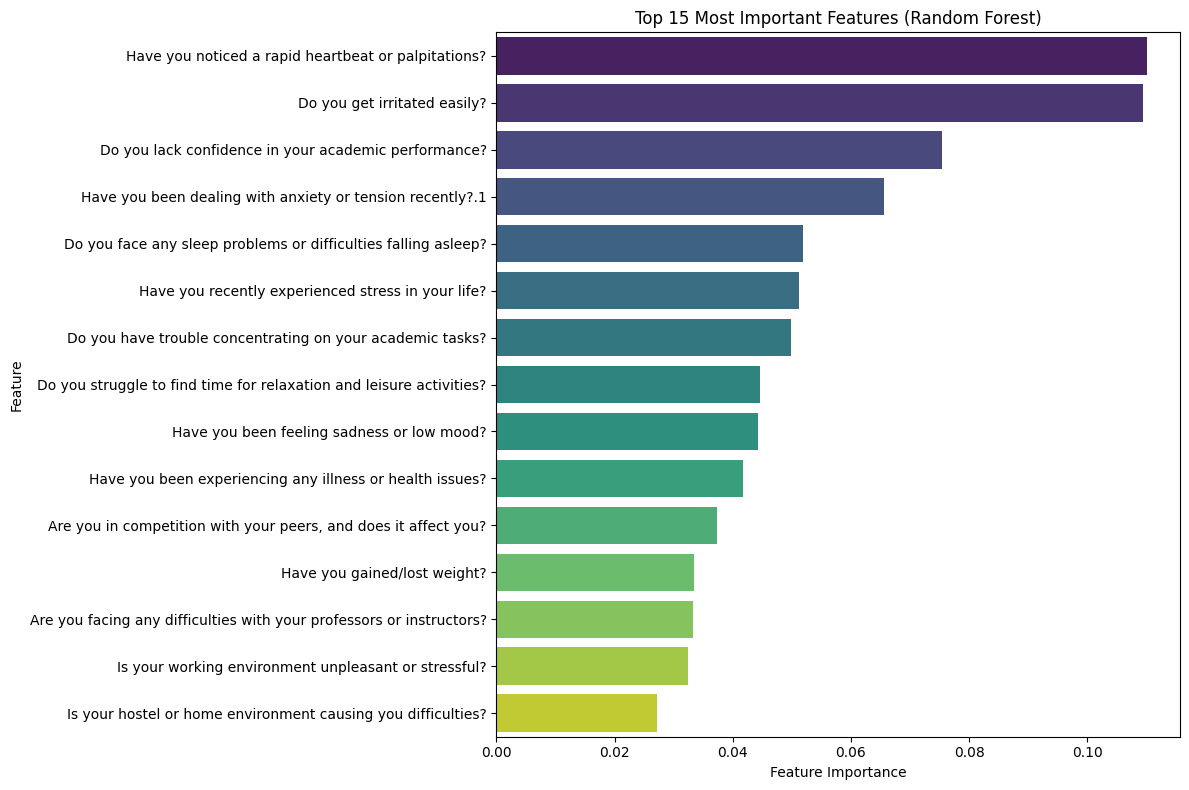

In [ ]:
# 2. Make a horizontal bar plot with the top 15 most important variables
plt.figure(figsize=(12, 8))
sns.barplot(x=top_15_features.values, y=top_15_features.index, palette='viridis')
plt.title('Top 15 Most Important Features (Random Forest)')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

### Logistic Regression Model Training and Evaluation

Ordinal Logistic Regression Classifier Evaluation:

Classification Report:
              precision    recall  f1-score   support

           0       0.22      0.67      0.33         6
           1       0.04      0.50      0.07         8
           2       0.89      0.22      0.35       150

    accuracy                           0.25       164
   macro avg       0.38      0.46      0.25       164
weighted avg       0.83      0.25      0.34       164

Macro F1-score: 0.2516

Accuracy: 0.2500



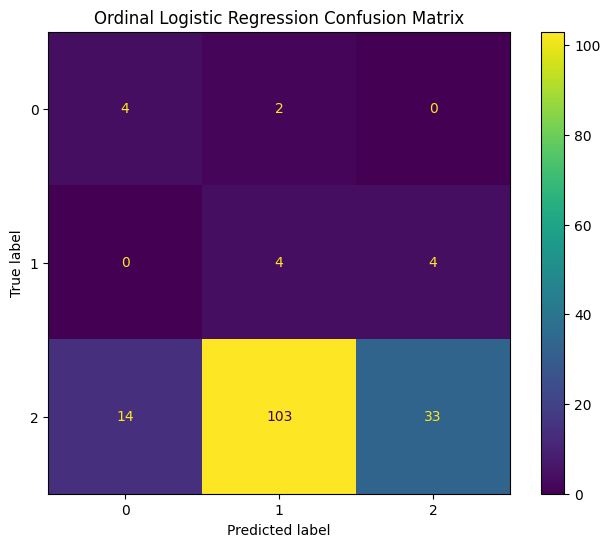

In [ ]:
# Install mord if not already installed
!pip install mord

import mord

# 1. Train an ordinal logistic regression model
ordinal_lr_model = mord.LogisticAT(alpha=1.0) # alpha is regularization strength, can be tuned
ordinal_lr_model.fit(X_train_res, y_train_res)

# Make predictions on the test set
y_pred_olr = ordinal_lr_model.predict(X_test)

print("Logistic Regression Classifier Evaluation:\n")

# Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred_olr))

# Macro F1-score
f1_macro_olr = f1_score(y_test, y_pred_olr, average='macro')
print(f"Macro F1-score: {f1_macro_olr:.4f}\n")

# Accuracy (for reference)
accuracy_olr = accuracy_score(y_test, y_pred_olr)
print(f"Accuracy: {accuracy_olr:.4f}\n")

# Confusion Matrix
cm_olr = confusion_matrix(y_test, y_pred_olr)
disp_olr = ConfusionMatrixDisplay(confusion_matrix=cm_olr, display_labels=ordinal_lr_model.classes_)
fig, ax = plt.subplots(figsize=(8, 6))
disp_olr.plot(cmap='viridis', ax=ax)
plt.title('Ordinal Logistic Regression Confusion Matrix')
plt.show()

### Model Performance Comparison

In [ ]:
# 3. Compare directly with Random Forest and XGBoost results

comparison_data = {
    'Model': ['Random Forest', 'XGBoost', 'Ordinal Logistic Regression'],
    'Macro F1-score': [f1_macro_rf, f1_macro_xgb, f1_macro_olr],
    'Accuracy': [accuracy_rf, accuracy_xgb, accuracy_olr]
}

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.sort_values(by='Macro F1-score', ascending=False).reset_index(drop=True)

display(Markdown("### Summary of Model Performance"))
display(comparison_df)

### Summary of Model Performance

,Model,Macro F1-score,Accuracy
0,Random Forest,0.805430,0.963415
1,XGBoost,0.768576,0.939024
2,Ordinal Logistic Regression,0.251550,0.250000


### Hyperparameter Tuning with GridSearchCV (Stratified 5-Fold Cross-Validation)

#### Random Forest Classifier Tuning

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best parameters for Random Forest: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 300}
Best Macro F1-score for Random Forest: 0.9921591180122633

Optimized Random Forest Classifier Evaluation:

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.50      0.60         6
           1       1.00      0.50      0.67         8
           2       0.96      0.99      0.97       150

    accuracy                           0.95       164
   macro avg       0.90      0.66      0.75       164
weighted avg       0.95      0.95      0.95       164

Macro F1-score: 0.7468

Accuracy: 0.9512



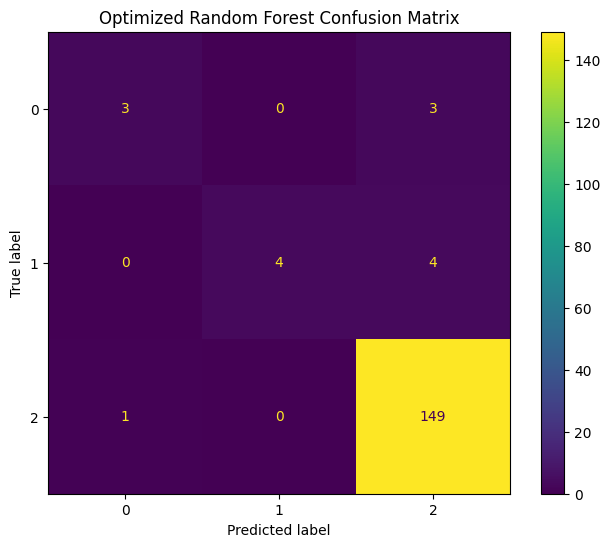

In [ ]:
from sklearn.model_selection import StratifiedKFold

# Define the parameter grid for Random Forest
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

# Initialize GridSearchCV
# Using the resampled data (X_train_res, y_train_res) for tuning
grid_search_rf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid_rf,
    scoring='f1_macro',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs=-1, # Use all available cores
    verbose=1
)

# Fit GridSearchCV to the training data
grid_search_rf.fit(X_train_res, y_train_res)

# Display best parameters and best score
print("Best parameters for Random Forest:", grid_search_rf.best_params_)
print("Best Macro F1-score for Random Forest:", grid_search_rf.best_score_)

# Get the best model
best_rf_model = grid_search_rf.best_estimator_

# Re-evaluate the best Random Forest model on the test set
y_pred_best_rf = best_rf_model.predict(X_test)

print("\nOptimized Random Forest Classifier Evaluation:\n")
print("Classification Report:")
print(classification_report(y_test, y_pred_best_rf))

f1_macro_best_rf = f1_score(y_test, y_pred_best_rf, average='macro')
print(f"Macro F1-score: {f1_macro_best_rf:.4f}\n")

accuracy_best_rf = accuracy_score(y_test, y_pred_best_rf)
print(f"Accuracy: {accuracy_best_rf:.4f}\n")

cm_best_rf = confusion_matrix(y_test, y_pred_best_rf)
disp_best_rf = ConfusionMatrixDisplay(confusion_matrix=cm_best_rf, display_labels=best_rf_model.classes_)
fig, ax = plt.subplots(figsize=(8, 6))
disp_best_rf.plot(cmap='viridis', ax=ax)
plt.title('Optimized Random Forest Confusion Matrix')
plt.show()

#### XGBoost Classifier Tuning

Fitting 5 folds for each of 18 candidates, totalling 90 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:48:31] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best parameters for XGBoost: {'learning_rate': 0.3, 'max_depth': 9, 'n_estimators': 100}
Best Macro F1-score for XGBoost: 0.9898961684793264

Optimized XGBoost Classifier Evaluation:

Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.83      0.71         6
           1       0.62      0.62      0.62         8
           2       0.97      0.96      0.97       150

    accuracy                           0.94       164
   macro avg       0.74      0.81      0.77       164
weighted avg       0.94      0.94      0.94       164

Macro F1-score: 0.7686

Accuracy: 0.9390



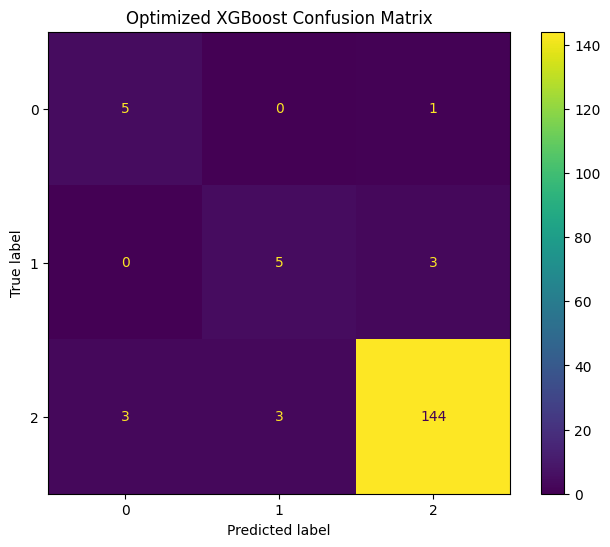

In [ ]:
# Define the parameter grid for XGBoost
param_grid_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 6, 9],
    'learning_rate': [0.01, 0.1, 0.3]
}

# Initialize GridSearchCV
grid_search_xgb = GridSearchCV(
    estimator=XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss'),
    param_grid=param_grid_xgb,
    scoring='f1_macro',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs=-1,
    verbose=1
)

# Fit GridSearchCV to the training data
grid_search_xgb.fit(X_train_res, y_train_res)

# Display best parameters and best score
print("Best parameters for XGBoost:", grid_search_xgb.best_params_)
print("Best Macro F1-score for XGBoost:", grid_search_xgb.best_score_)

# Get the best model
best_xgb_model = grid_search_xgb.best_estimator_

# Re-evaluate the best XGBoost model on the test set
y_pred_best_xgb = best_xgb_model.predict(X_test)

print("\nOptimized XGBoost Classifier Evaluation:\n")
print("Classification Report:")
print(classification_report(y_test, y_pred_best_xgb))

f1_macro_best_xgb = f1_score(y_test, y_pred_best_xgb, average='macro')
print(f"Macro F1-score: {f1_macro_best_xgb:.4f}\n")

accuracy_best_xgb = accuracy_score(y_test, y_pred_best_xgb)
print(f"Accuracy: {accuracy_best_xgb:.4f}\n")

cm_best_xgb = confusion_matrix(y_test, y_pred_best_xgb)
disp_best_xgb = ConfusionMatrixDisplay(confusion_matrix=cm_best_xgb, display_labels=best_xgb_model.classes_)
fig, ax = plt.subplots(figsize=(8, 6))
disp_best_xgb.plot(cmap='viridis', ax=ax)
plt.title('Optimized XGBoost Confusion Matrix')
plt.show()

### Final Model Performance Comparison (Including Tuned Models)

In [ ]:
# Update comparison data with optimized models
comparison_data_tuned = {
    'Model': [
        'Random Forest (Untuned)', 'XGBoost (Untuned)', 'Ordinal Logistic Regression',
        'Random Forest (Tuned)', 'XGBoost (Tuned)'
    ],
    'Macro F1-score': [
        f1_macro_rf, f1_macro_xgb, f1_macro_olr,
        f1_macro_best_rf, f1_macro_best_xgb
    ],
    'Accuracy': [
        accuracy_rf, accuracy_xgb, accuracy_olr,
        accuracy_best_rf, accuracy_best_xgb
    ]
}

comparison_df_tuned = pd.DataFrame(comparison_data_tuned)
comparison_df_tuned = comparison_df_tuned.sort_values(by='Macro F1-score', ascending=False).reset_index(drop=True)

display(Markdown("### Summary of Model Performance (Untuned vs. Tuned Models)"))
display(comparison_df_tuned)

### Summary of Model Performance (Untuned vs. Tuned Models)

,Model,Macro F1-score,Accuracy
0,Random Forest (Untuned),0.805430,0.963415
1,XGBoost (Untuned),0.768576,0.939024
2,XGBoost (Tuned),0.768576,0.939024
3,Random Forest (Tuned),0.746841,0.951220
4,Ordinal Logistic Regression,0.251550,0.250000


### Interpretabilidade do Modelo com SHAP (Random Forest Não Ajustado)

Vamos usar a biblioteca SHAP (SHapley Additive exPlanations) para explicar as previsões do melhor modelo (Random Forest não ajustado) de forma mais transparente. O SHAP atribui a cada feature uma "contribuição de Shapley" para a previsão de uma instância, permitindo-nos entender o impacto de cada feature.


In [ ]:
# 1. Criar um explainer SHAP para o modelo Random Forest (untuned)
# best_rf_model é o Random Forest Tuned, rf_model é o Random Forest Untuned
explainer = shap.TreeExplainer(rf_model)

# 2. Calcular os valores SHAP para X_test
# Para modelos multi-classe, shap_values será uma lista de arrays, um para cada classe
shap_values = explainer.shap_values(X_test)

print(f"Shape dos SHAP values: {len(shap_values)} classes, cada uma com shape {shap_values[0].shape}")


Shape dos SHAP values: 164 classes, cada uma com shape (25, 3)


#### 1. Importância Global das Features (Bar Plot)

Este gráfico mostra a importância média absoluta de cada feature em todas as previsões. Features mais acima contribuem mais para a magnitude da previsão.


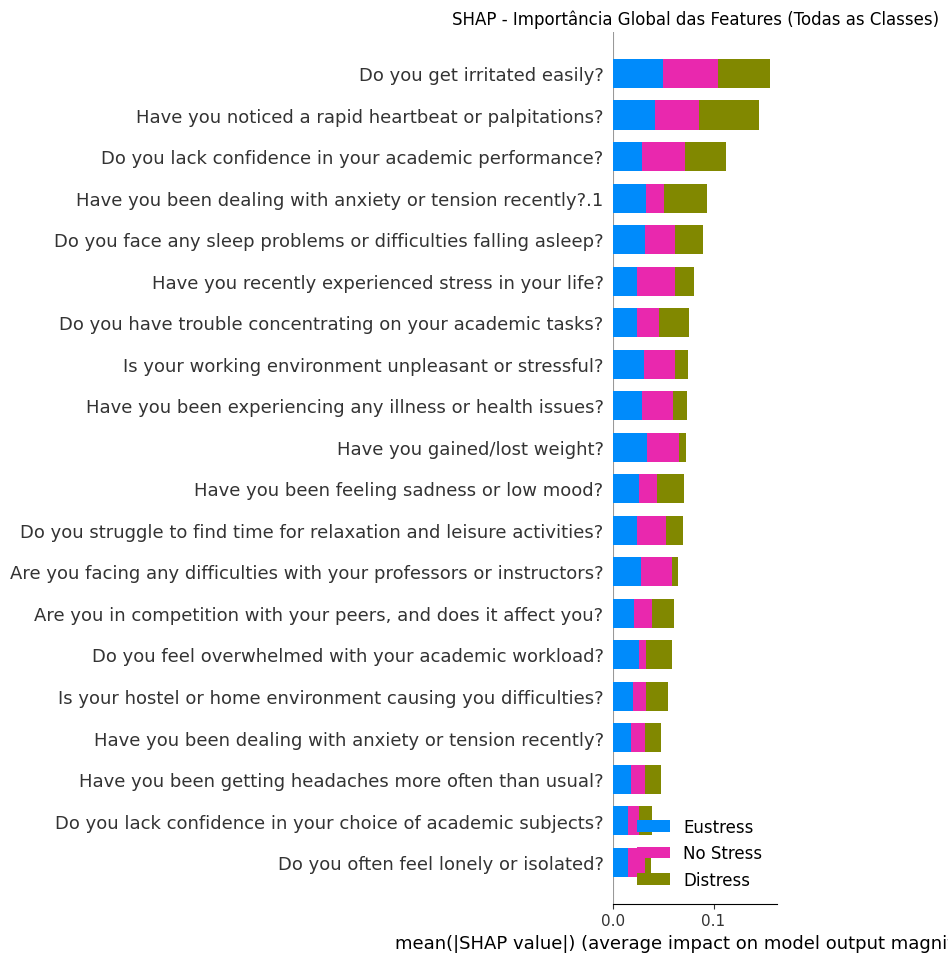

In [ ]:
# Para o summary_plot com plot_type='bar', shap.summary_plot pode receber a lista de shap_values
# ou apenas shap_values[class_idx] para focar numa classe.
# Para importância global, a biblioteca SHAP consegue agregar a informação.
shap.summary_plot(shap_values, X_test, plot_type='bar', class_names=['Distress', 'No Stress', 'Eustress'], show=False)
plt.title('SHAP - Importância Global das Features (Todas as Classes)')
plt.show()


#### 2. Impacto Direcional das Features (Beeswarm Plot)

Este gráfico mostra o impacto de cada feature nas previsões do modelo para todas as instâncias no conjunto de teste. Cada ponto representa uma instância no conjunto de teste. A cor indica o valor da feature (vermelho = alto, azul = baixo) e a posição horizontal indica o impacto na previsão do modelo.



SHAP Summary Plot para a Classe: Distress (0)


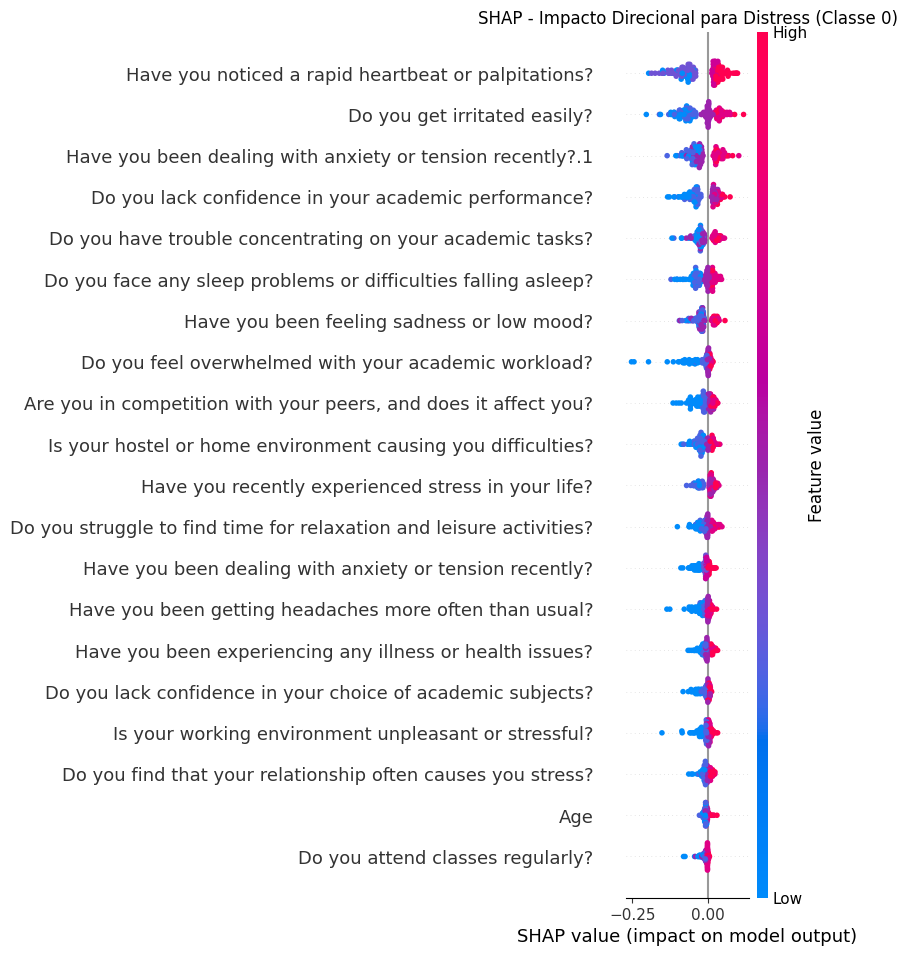


SHAP Summary Plot para a Classe: No Stress (1)


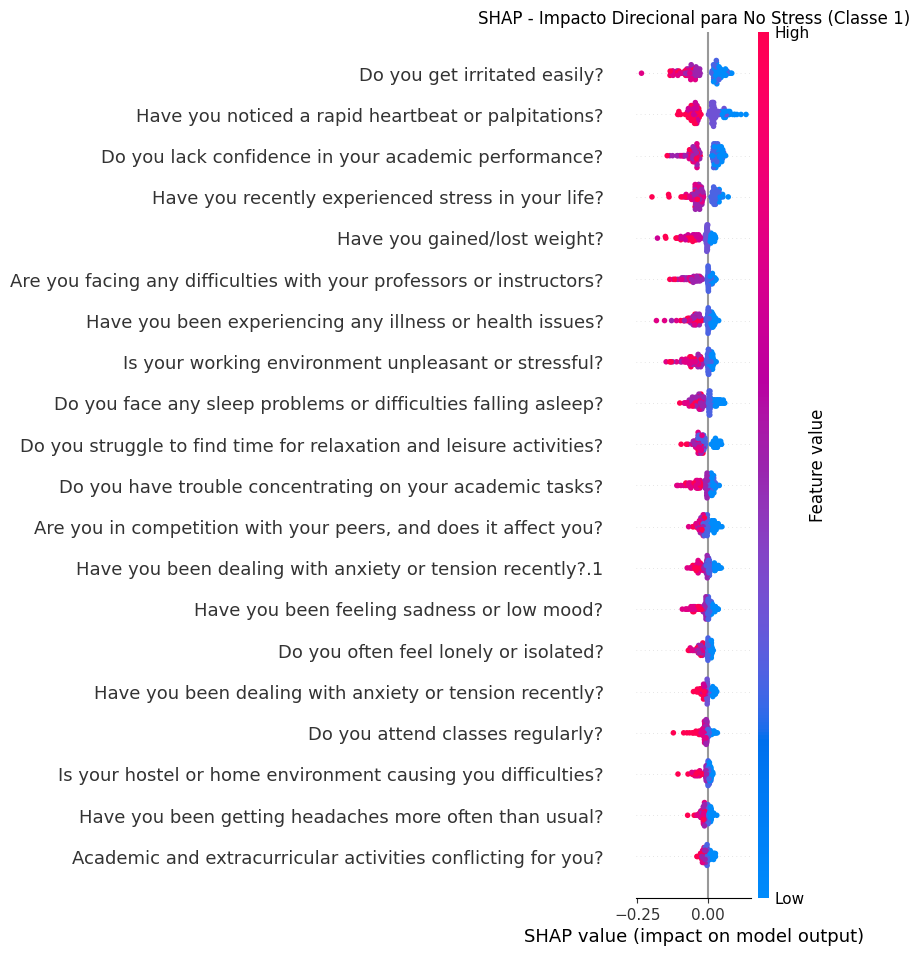


SHAP Summary Plot para a Classe: Eustress (2)


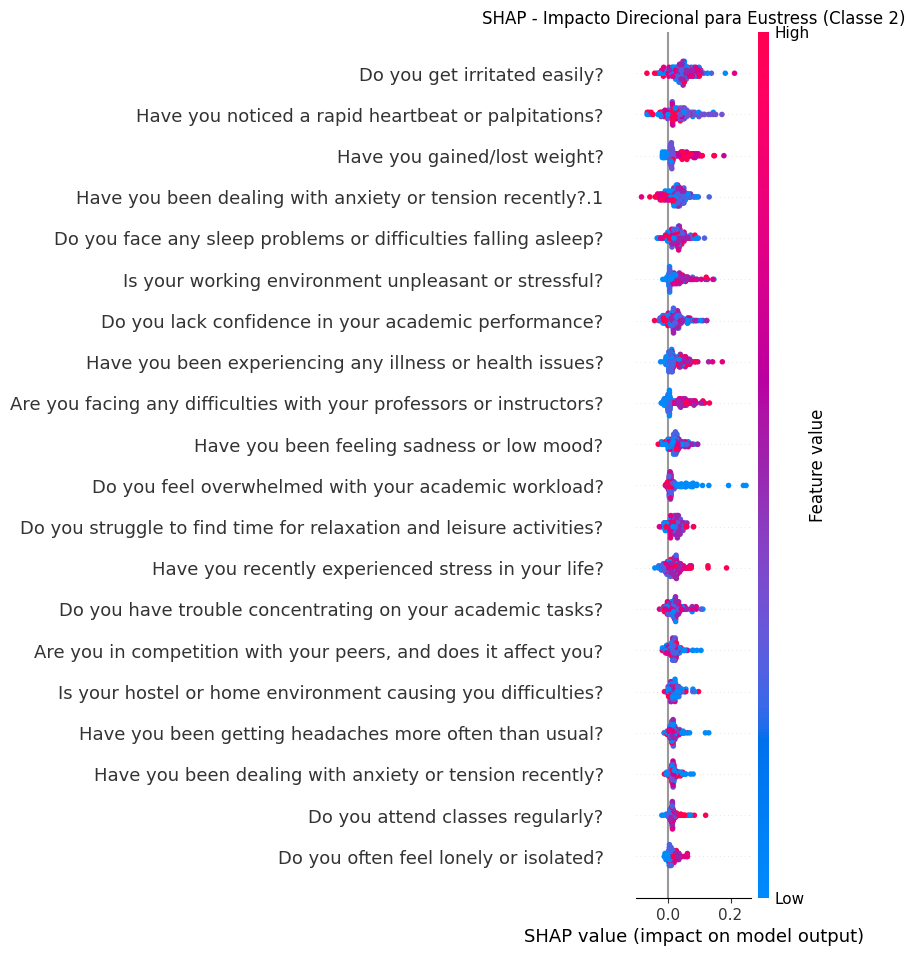

In [ ]:
# O beeswarm plot é melhor visualizado para uma única classe de cada vez.
# Vamos gerar um para cada classe ou o plot padrão do SHAP que tenta mostrar todas as classes.
# shap.summary_plot(shap_values, X_test, class_names=['Distress', 'No Stress', 'Eustress'], show=False)
# plt.title('SHAP - Impacto Direcional das Features (Todas as Classes)')
# plt.show()

# Para uma visão mais clara, podemos focar nas classes individuais.
# SHAP plot para a classe 0 (Distress)
print("\nSHAP Summary Plot para a Classe: Distress (0)")
shap.summary_plot(shap_values[:, :, 0], X_test, show=False)
plt.title('SHAP - Impacto Direcional para Distress (Classe 0)')
plt.show()

# SHAP plot para a classe 1 (No Stress)
print("\nSHAP Summary Plot para a Classe: No Stress (1)")
shap.summary_plot(shap_values[:, :, 1], X_test, show=False)
plt.title('SHAP - Impacto Direcional para No Stress (Classe 1)')
plt.show()

# SHAP plot para a classe 2 (Eustress)
print("\nSHAP Summary Plot para a Classe: Eustress (2)")
shap.summary_plot(shap_values[:, :, 2], X_test, show=False)
plt.title('SHAP - Impacto Direcional para Eustress (Classe 2)')
plt.show()


#### 3. Explicação de Previsões Individuais (Waterfall Plots)

Estes gráficos mostram como as features contribuíram para a previsão de uma instância específica. Cada barra representa a contribuição de uma feature, empurrando a previsão da base_value (previsão média) para a previsão final do modelo para essa instância.

Vamos selecionar um caso de 'Distress' (0) e um caso de 'Eustress' (2) do conjunto de teste.


Exemplo de Distress encontrado no índice original 516 (índice em X_test: 2)
Exemplo de No Stress encontrado no índice original 138 (índice em X_test: 22)
Exemplo de Eustress encontrado no índice original 583 (índice em X_test: 0)

Waterfall Plot para um caso de Distress (Classe 0):


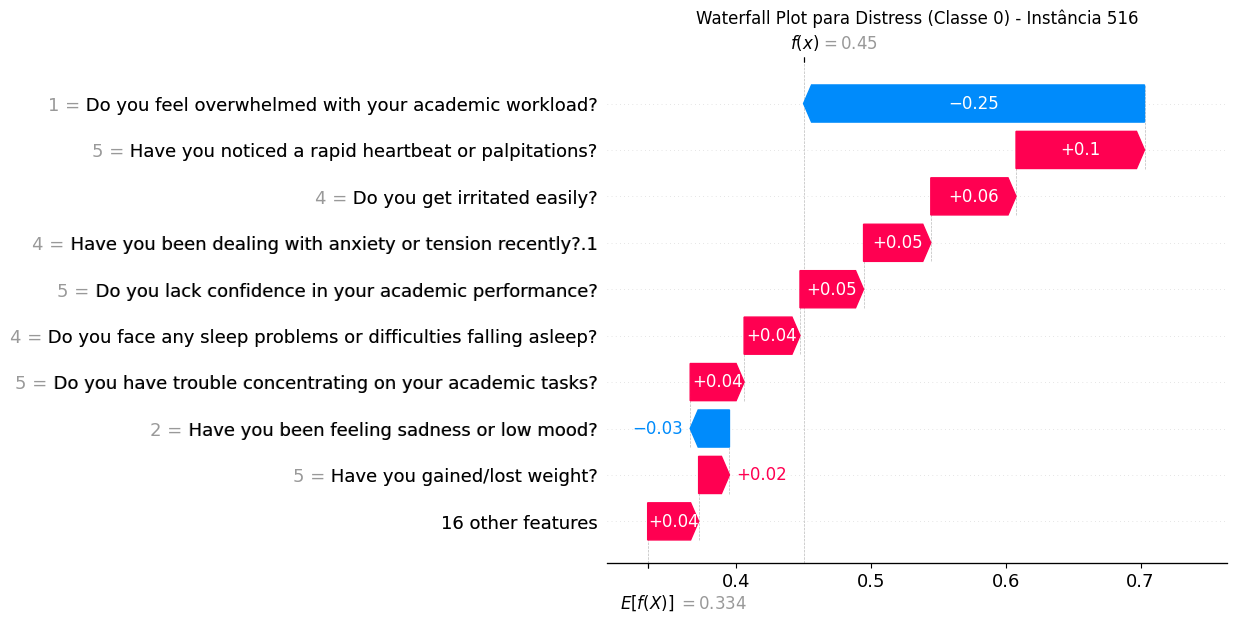


Waterfall Plot para um caso de No Stress (Classe 1):


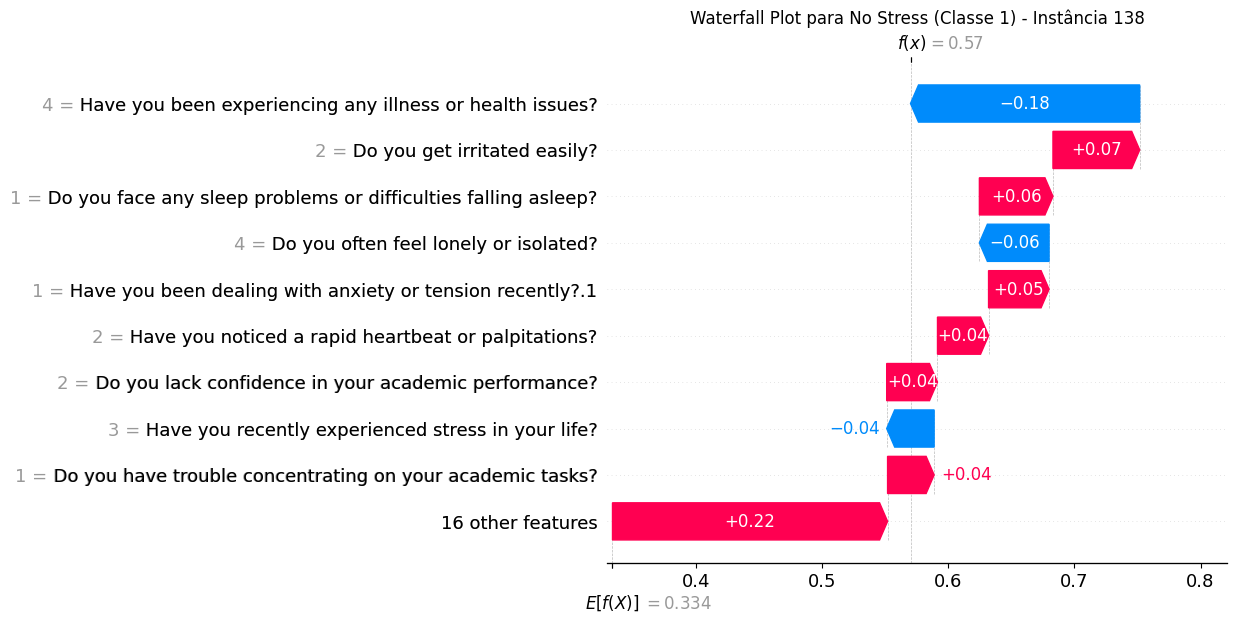


Waterfall Plot para um caso de Eustress (Classe 2):


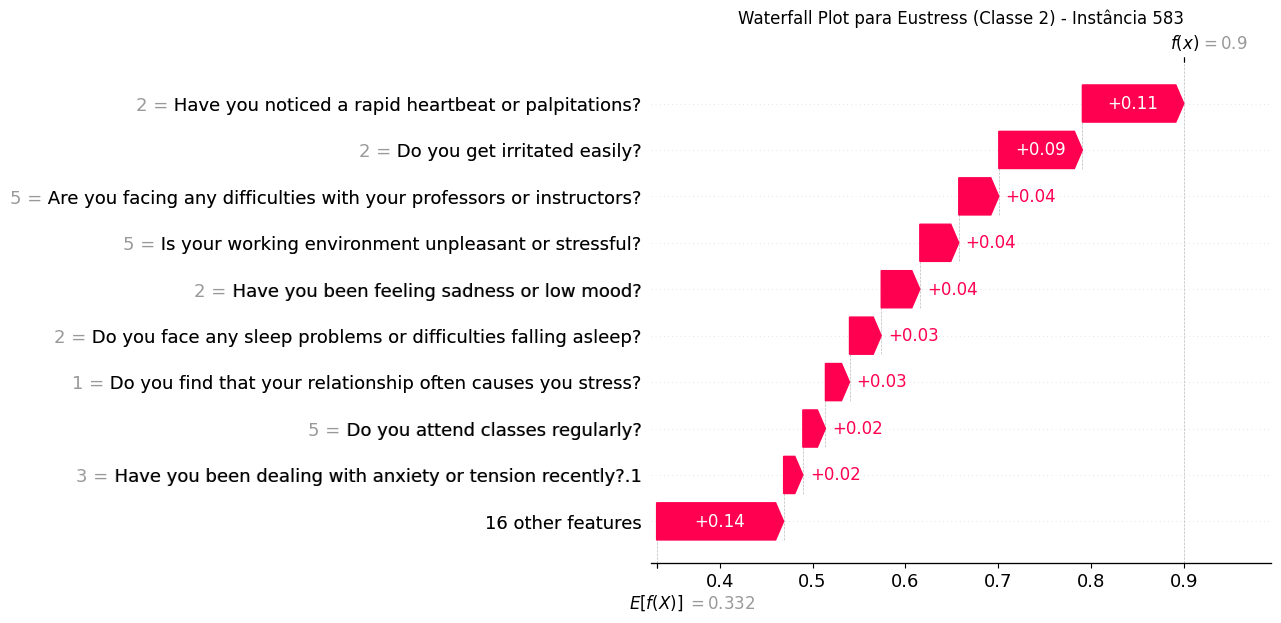

In [ ]:
# Encontrar um índice para um caso de Distress (Classe 0) no X_test
distress_indices = y_test[y_test == 0].index
if len(distress_indices) > 0:
    distress_example_idx_original = distress_indices[0]
    # Converter o índice original do DataFrame df para o índice no X_test
    distress_example_idx_X_test = X_test.index.get_loc(distress_example_idx_original)
    print(f"Exemplo de Distress encontrado no índice original {distress_example_idx_original} (índice em X_test: {distress_example_idx_X_test})")
else:
    distress_example_idx_X_test = None
    print("Nenhum exemplo de Distress encontrado no conjunto de teste.")

# Encontrar um índice para um caso de No Stress (Classe 1) no X_test
nostress_indices = y_test[y_test == 1].index
if len(nostress_indices) > 0:
    nostress_example_idx_original = nostress_indices[0]
    # Converter o índice original do DataFrame df para o índice no X_test
    nostress_example_idx_X_test = X_test.index.get_loc(nostress_example_idx_original)
    print(f"Exemplo de No Stress encontrado no índice original {nostress_example_idx_original} (índice em X_test: {nostress_example_idx_X_test})")
else:
    nostress_example_idx_X_test = None
    print("Nenhum exemplo de No Stress encontrado no conjunto de teste.")

# Encontrar um índice para um caso de Eustress (Classe 2) no X_test
eustress_indices = y_test[y_test == 2].index
if len(eustress_indices) > 0:
    eustress_example_idx_original = eustress_indices[0]
    # Converter o índice original do DataFrame df para o índice no X_test
    eustress_example_idx_X_test = X_test.index.get_loc(eustress_example_idx_original)
    print(f"Exemplo de Eustress encontrado no índice original {eustress_example_idx_original} (índice em X_test: {eustress_example_idx_X_test})")
else:
    eustress_example_idx_X_test = None
    print("Nenhum exemplo de Eustress encontrado no conjunto de teste.")

# Plotar waterfall para o caso de Distress (se encontrado)
if distress_example_idx_X_test is not None:
    print("\nWaterfall Plot para um caso de Distress (Classe 0):")
    # shap.waterfall_plot espera um Explanation object ou um array de SHAP values para um único sample
    # E o valor base. Para multi-classe, podemos explicar a previsão para a classe 0.
    shap.plots.waterfall(shap.Explanation(values=shap_values[distress_example_idx_X_test, :, 0],
                                        base_values=explainer.expected_value[0],
                                        data=X_test.iloc[distress_example_idx_X_test]), show=False)
    plt.title(f'Waterfall Plot para Distress (Classe 0) - Instância {distress_example_idx_original}')
    plt.show()

# Plotar waterfall para o caso de No Stress (se encontrado)
if nostress_example_idx_X_test is not None:
    print("\nWaterfall Plot para um caso de No Stress (Classe 1):")
    # Para multi-classe, podemos explicar a previsão para a classe 1.
    shap.plots.waterfall(shap.Explanation(values=shap_values[nostress_example_idx_X_test, :, 1],
                                        base_values=explainer.expected_value[1],
                                        data=X_test.iloc[nostress_example_idx_X_test]), show=False)
    plt.title(f'Waterfall Plot para No Stress (Classe 1) - Instância {nostress_example_idx_original}')
    plt.show()

# Plotar waterfall para o caso de Eustress (se encontrado)
if eustress_example_idx_X_test is not None:
    print("\nWaterfall Plot para um caso de Eustress (Classe 2):")
    # Para multi-classe, podemos explicar a previsão para a classe 2.
    shap.plots.waterfall(shap.Explanation(values=shap_values[eustress_example_idx_X_test, :, 2],
                                        base_values=explainer.expected_value[2],
                                        data=X_test.iloc[eustress_example_idx_X_test]), show=False)
    plt.title(f'Waterfall Plot para Eustress (Classe 2) - Instância {eustress_example_idx_original}')
    plt.show()


### Análise de Falsos Negativos Críticos (Distress Classificado como Eustress)

Vamos focar nos casos mais críticos de erro do modelo: quando ele prevê 'Eustress' (Classe 2) para indivíduos que, na verdade, estão em 'Distress' (Classe 0). Este é um erro particularmente perigoso, pois subestima uma situação de stress negativo.

In [ ]:
# 1. Isolar os falsos negativos de Distress (Classe 0 -> Classe 2)
false_negatives_distress_indices = y_test[(y_test == 0) & (y_pred_rf == 2)].index

if len(false_negatives_distress_indices) > 0:
    display(Markdown(f"**{len(false_negatives_distress_indices)}** casos de 'Distress' foram classificados incorretamente como 'Eustress' (Falsos Negativos Críticos)."))

    # Obter os dados de X_test para estes falsos negativos
    X_false_negatives_distress = X_test.loc[false_negatives_distress_indices]

    # 2. Isolar os Distress correctamente classificados (Classe 0 -> Classe 0)
    true_positives_distress_indices = y_test[(y_test == 0) & (y_pred_rf == 0)].index
    X_true_positives_distress = X_test.loc[true_positives_distress_indices]

    if len(true_positives_distress_indices) > 0:
        display(Markdown(f"**{len(true_positives_distress_indices)}** casos de 'Distress' foram classificados corretamente como 'Distress' (Verdadeiros Positivos)."))

        # 3. Mostrar o perfil médio dos falsos negativos vs. correctamente classificados
        mean_profile_false_negatives = X_false_negatives_distress.mean()
        mean_profile_true_positives = X_true_positives_distress.mean()

        comparison_df_profiles = pd.DataFrame({
            'Mean_False_Negatives_Distress_as_Eustress': mean_profile_false_negatives,
            'Mean_True_Positives_Distress': mean_profile_true_positives
        })

        display(Markdown("### Perfil Médio de Falsos Negativos Críticos vs. Distress Correto"))
        display(comparison_df_profiles.sort_values(by='Mean_True_Positives_Distress', ascending=False))

        # 4. Calcular a taxa de erro crítico
        total_distress_actual = (y_test == 0).sum()
        critical_error_rate = (len(false_negatives_distress_indices) / total_distress_actual) * 100

        display(Markdown(f"\n### Taxa de Erro Crítico (Distress classificado como Eustress): {critical_error_rate:.2f}% dos casos reais de Distress"))

        # 5. Comentar: o modelo erra mais em que tipo de perfil?
        display(Markdown("### Comentários sobre o Perfil de Erro Crítico:"))
        display(Markdown("Para analisar o perfil em que o modelo erra mais (classificando Distress como Eustress), devemos observar as diferenças entre a coluna `Mean_False_Negatives_Distress_as_Eustress` e `Mean_True_Positives_Distress` no quadro acima. Valores mais altos ou mais baixos em certas características para os Falsos Negativos podem indicar um perfil onde o modelo tem dificuldade."))

        # Optional: Highlight significant differences
        diff_profiles = comparison_df_profiles['Mean_False_Negatives_Distress_as_Eustress'] - comparison_df_profiles['Mean_True_Positives_Distress']
        significant_diffs = diff_profiles[abs(diff_profiles) > 0.5] # Threshold for 'significant' difference
        if not significant_diffs.empty:
            display(Markdown("**Características com as maiores diferenças (Falsos Negativos - Verdadeiros Positivos):**"))
            display(significant_diffs.sort_values(ascending=False).to_frame(name='Difference'))
            display(Markdown("\nIsso sugere que, para esses falsos negativos, o modelo pode estar sendo 'enganado' por características que se assemelham mais a um estado de 'Eustress' (ou a ausência de sintomas típicos de 'Distress'), mesmo quando a realidade é negativa."))
        else:
            display(Markdown("Não foram encontradas diferenças significativas (>0.5) entre os perfis médios dos Falsos Negativos e Verdadeiros Positivos de Distress."))

    else:
        display(Markdown("Não há casos de 'Distress' corretamente classificados (Verdadeiros Positivos) para comparação."))
else:
    display(Markdown("Nenhum falso negativo crítico (Distress classificado como Eustress) encontrado para análise."))

**3** casos de 'Distress' foram classificados incorretamente como 'Eustress' (Falsos Negativos Críticos).

**3** casos de 'Distress' foram classificados corretamente como 'Distress' (Verdadeiros Positivos).

### Perfil Médio de Falsos Negativos Críticos vs. Distress Correto

,Mean_False_Negatives_Distress_as_Eustress,Mean_True_Positives_Distress
Age,20.333333,20.000000
Do you get irritated easily?,3.333333,4.666667
Have you noticed a rapid heartbeat or palpitations?,4.333333,4.666667
Have you been dealing with anxiety or tension recently?,4.000000,4.666667
Have you been dealing with anxiety or tension recently?.1,3.666667,4.666667
Have you been getting headaches more often than usual?,4.333333,4.666667
Do you face any sleep problems or difficulties falling asleep?,3.333333,4.333333
Do you feel overwhelmed with your academic workload?,1.666667,4.333333
Have you recently experienced stress in your life?,4.333333,4.000000
Do you often feel lonely or isolated?,4.000000,4.000000



### Taxa de Erro Crítico (Distress classificado como Eustress): 50.00% dos casos reais de Distress

### Comentários sobre o Perfil de Erro Crítico:

Para analisar o perfil em que o modelo erra mais (classificando Distress como Eustress), devemos observar as diferenças entre a coluna `Mean_False_Negatives_Distress_as_Eustress` e `Mean_True_Positives_Distress` no quadro acima. Valores mais altos ou mais baixos em certas características para os Falsos Negativos podem indicar um perfil onde o modelo tem dificuldade.

**Características com as maiores diferenças (Falsos Negativos - Verdadeiros Positivos):**

,Difference
Is your hostel or home environment causing you difficulties?,2.333333
Do you lack confidence in your choice of academic subjects?,1.666667
Academic and extracurricular activities conflicting for you?,1.333333
Do you struggle to find time for relaxation and leisure activities?,1.000000
Do you have trouble concentrating on your academic tasks?,1.000000
Do you find that your relationship often causes you stress?,0.666667
Do you attend classes regularly?,0.666667
Is your working environment unpleasant or stressful?,0.666667
"Are you in competition with your peers, and does it affect you?",0.666667
Do you lack confidence in your academic performance?,0.666667



Isso sugere que, para esses falsos negativos, o modelo pode estar sendo 'enganado' por características que se assemelham mais a um estado de 'Eustress' (ou a ausência de sintomas típicos de 'Distress'), mesmo quando a realidade é negativa.

As pessoas que o modelo 'errou' (Disstress como Eustress) geralmente tinham sintomas de stress negativo menos pronunciados (menos ansiedade, problemas de sono, irritabilidade, tristeza) do que as pessoas com 'Distress' que o modelo acertou. Por outro lado, para esses casos de erro, características como 'dificuldade em concentrar nas tarefas académicas' ou 'conflito entre atividades' estavam mais elevadas. Isso apoia a ideia: o modelo pode interpretar esses sinais como parte de um 'Eustress' (desafio, foco), quando na verdade eram de 'Distress' porque os sinais internos de sobrecarga estavam mais 'escondidos' ou menos intensos.